# Feature Engineering v4

Feature:

Bollinger Band Width

Objective:

Measure Price Space to historical baseline.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
path = r"C:\Users\LENOVO\AlgoTrading_Research\statistical-range-detection\data\processed\eurusd_h1_features_v3.csv"
df = pd.read_csv(path, parse_dates=["date"], index_col="date")

In [3]:
df["sma20"] = df["close"].rolling(20).mean()
df["std20"] = df["close"].rolling(20).std()

In [4]:
df["upper"] = (df["sma20"] + 2 * df["std20"])
df["lower"] = (df["sma20"] - 2 * df["std20"])
df["bb_width"] = (df["upper"] - df["lower"])
df["bb_width"] = (df["bb_width"] / df["sma20"])

In [5]:
df["bb_mean_16"] = (df["bb_width"].rolling(16).mean())
df["bb_mean_48"] = (df["bb_width"].rolling(48).mean())

In [6]:
df["bb_rel_16"] = (df["bb_width"] / df["bb_mean_16"])
df["bb_rel_48"] = (df["bb_width"] / df["bb_mean_48"])

In [7]:
df = df.dropna()
df[["bb_rel_16", "bb_rel_48"]].describe()

,bb_rel_16,bb_rel_48
count,18759.000000,18759.000000
mean,1.038556,1.031353
std,0.423578,0.554549
min,0.117302,0.160934
25%,0.744345,0.650587
50%,0.988014,0.907852
75%,1.266159,1.273820
max,3.765329,5.465471


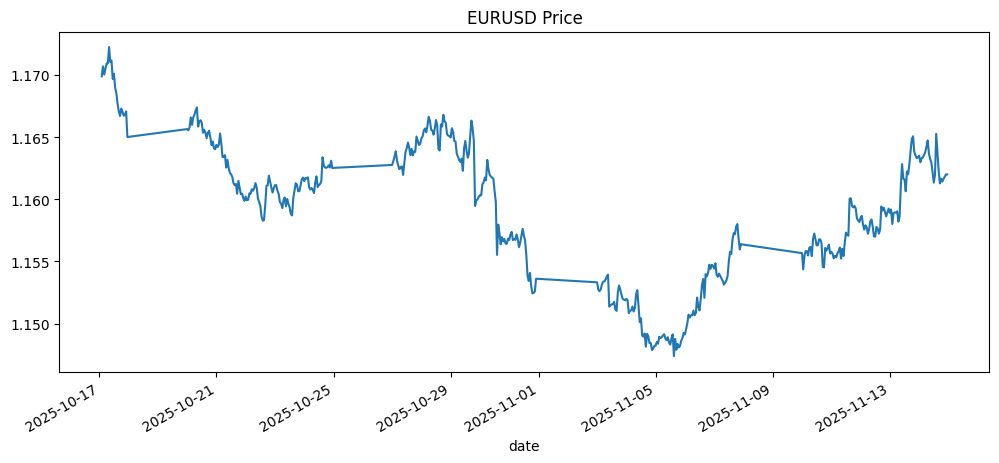

In [8]:
df["close"].iloc[-500:].plot(figsize=(12,5))

plt.title("EURUSD Price")
plt.show()

<Figure size 1200x500 with 0 Axes>

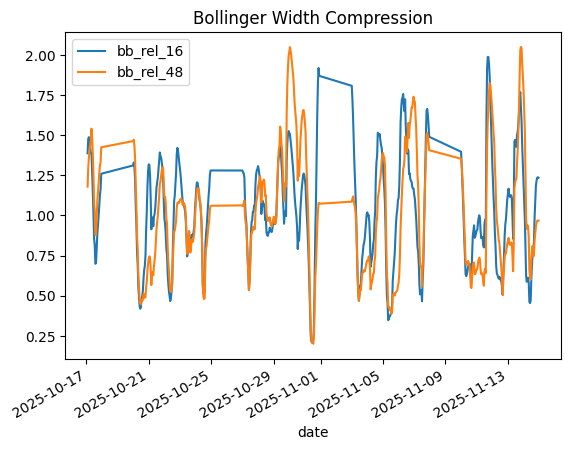

In [9]:
plt.figure(figsize=(12,5))

df[["bb_rel_16","bb_rel_48"]].iloc[-500:].plot()
plt.title("Bollinger Width Compression")

plt.savefig("C:/Users/LENOVO/AlgoTrading_Research/statistical-range-detection/figures/bb_validation_v4.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1400x600 with 0 Axes>

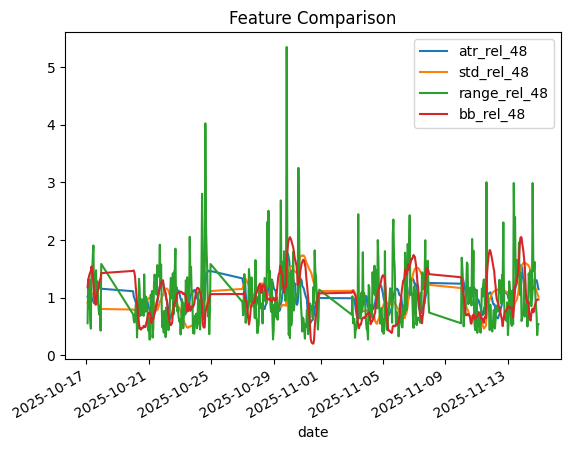

In [10]:
plt.figure(figsize=(14,6))

df[["atr_rel_48", "std_rel_48", "range_rel_48", "bb_rel_48"]].iloc[-500:].plot()
plt.title("Feature Comparison")

plt.savefig("C:/Users/LENOVO/AlgoTrading_Research/statistical-range-detection/figures/features_compare_v1.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
df.to_csv(r"C:\Users\LENOVO\AlgoTrading_Research\statistical-range-detection\data\processed\eurusd_h1_features_v4.csv")